### Question 1



In [19]:
# import the important packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # library for visualizations

#%matplotlib inline

import scipy.stats as stats  # this library contains a large number of probability distributions as well as a growing library of statistical functions
from scipy.stats import norm

In [2]:
from scipy.stats import chi2_contingency

In [20]:

total_injured = 145
total_not_injured = 90
total_players = 235

data = {
    "Position": ["Striker", "Forward", "Attacking Midfielder", "Winger"],
    "Injured": [45, 56, 24, 20],
    "Not Injured": [32, 38, 11, 9],
    "Total": [77, 94, 35, 29]
}
df = pd.DataFrame(data)

In [7]:
p_injured = total_injured / total_players
p_forward_or_winger = (94 + 29) / total_players
p_striker_and_injured = 45 / total_players
p_striker_given_injured = 45 / total_injured

print("** Probability Results **")
print("1.1 P(Injured)                  =", round(p_injured, 3), "(", round(p_injured * 100, 1), "% )")
print("1.2 P(Forward or Winger)        =", round(p_forward_or_winger, 3), "(", round(p_forward_or_winger * 100, 1), "% )")
print("1.3 P(Striker who is Injured)        =", round(p_striker_and_injured, 3), "(", round(p_striker_and_injured * 100, 1), "% )")
print("1.4 P(Random chosen player is injured)        =", round(p_striker_given_injured, 3), "(", round(p_striker_given_injured * 100, 1), "% )")


** Probability Results **
1.1 P(Injured)                  = 0.617 ( 61.7 % )
1.2 P(Forward or Winger)        = 0.523 ( 52.3 % )
1.3 P(Striker who is Injured)        = 0.191 ( 19.1 % )
1.4 P(Random chosen player is injured)        = 0.31 ( 31.0 % )


### Question 2

In [21]:
# Parameters from problem statement
mu = 5         # mean breaking strength
sigma = 1.5    # standard deviation
n = 10000      # number of samples for simulation

# Generate and sort random samples from N(5, 1.5^2)
samples = np.random.randn(n) * sigma + mu
samples = np.sort(samples)  # sorted for smooth plots

# To plot histogram + KDE + shaded region
def plot_area(condition, title, color='skyblue'):
    plt.figure(figsize=(8, 4))
    sns.histplot(samples, bins=50, stat="density", color="lightgrey", kde=True, label="Density")
    plt.fill_between(samples, 0, norm.pdf(samples, mu, sigma), where=condition, color=color, alpha=0.6)
    plt.title(title)
    plt.xlabel("Breaking Strength (kg/sq cm)")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.show()

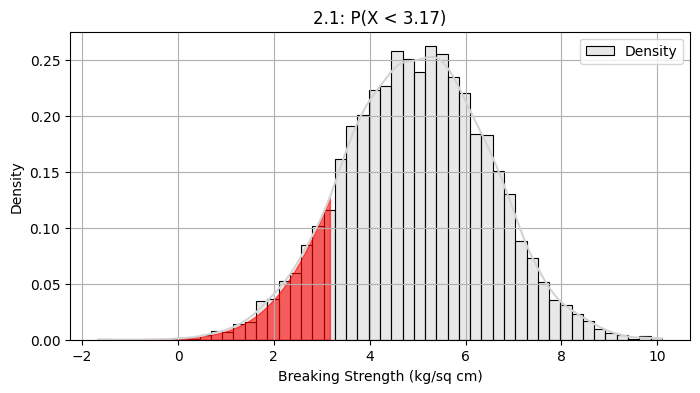

2.1: P(X < 3.17) = 0.1112


In [22]:
# 2.1: P(X < 3.17)
p1 = norm.cdf(3.17, mu, sigma)
plot_area(samples < 3.17, "2.1: P(X < 3.17)", color="red")
print("2.1: P(X < 3.17) =", round(p1, 4))


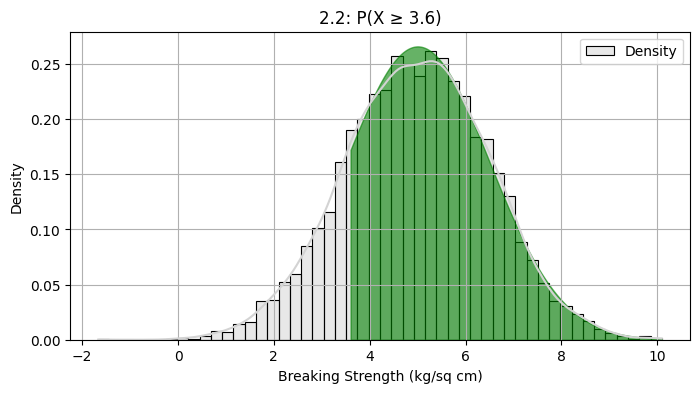

2.2: P(X ≥ 3.6) = 0.8247


In [23]:
# 2.2: P(X ≥ 3.6)
p2 = 1 - norm.cdf(3.6, mu, sigma)
plot_area(samples >= 3.6, "2.2: P(X ≥ 3.6)", color="green")
print("2.2: P(X ≥ 3.6) =", round(p2, 4))

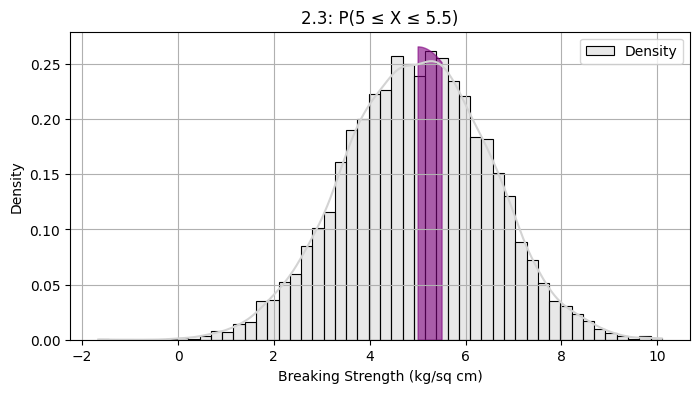

2.3: P(5 ≤ X ≤ 5.5) = 0.1306


In [24]:
# 2.3: P(5 ≤ X ≤ 5.5)
p3 = norm.cdf(5.5, mu, sigma) - norm.cdf(5, mu, sigma)
plot_area((samples >= 5) & (samples <= 5.5), "2.3: P(5 ≤ X ≤ 5.5)", color="purple")
print("2.3: P(5 ≤ X ≤ 5.5) =", round(p3, 4))


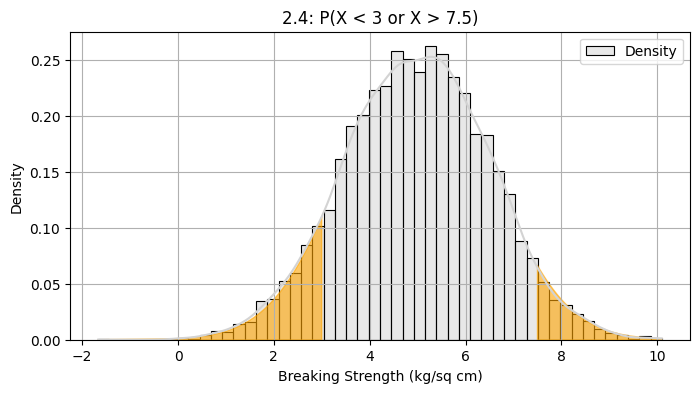

2.4: P(X < 3 or X > 7.5) = 0.139


In [25]:
# 2.4: P(X < 3 or X > 7.5)
p4 = norm.cdf(3, mu, sigma) + (1 - norm.cdf(7.5, mu, sigma))
plot_area((samples < 3) | (samples > 7.5), "2.4: P(X < 3 or X > 7.5)", color="orange")
print("2.4: P(X < 3 or X > 7.5) =", round(p4, 4))

In [27]:
# Summary
print("Summary:")
print("2.1: P(X < 3.17)         =", round(p1, 4))
print("2.2: P(X ≥ 3.6)          =", round(p2, 4))
print("2.3: P(5 ≤ X ≤ 5.5)      =", round(p3, 4))
print("2.4: P(X < 3 or X > 7.5) =", round(p4, 4))

Summary:
2.1: P(X < 3.17)         = 0.1112
2.2: P(X ≥ 3.6)          = 0.8247
2.3: P(5 ≤ X ≤ 5.5)      = 0.1306
2.4: P(X < 3 or X > 7.5) = 0.139


2.1 Approximately 11.12% of the gunny bags exhibit a breaking strength below 3.17 kg per sq cm. This corresponds to a Z-score of -1.22.

2.2 About 82.47% of the gunny bags possess a breaking strength equal to or exceeding 3.6 kg per sq cm. The Z-score for this value is -0.93.

2.3 The proportion of gunny bags with a breaking strength falling between 5 and 5.5 kg per sq cm is around 13.06%. These strengths correspond to Z-scores of 0.00 and 0.33, respectively.

2.4 Roughly 13.90% of the gunny bags have a breaking strength that falls outside the range of 3 to 7.5 kg per sq cm. The Z-scores for 3 and 7.5 are -1.33 and 1.67, respectively.

### Question 3

In [13]:
import os
print(os.listdir())

['.config', 'sample_data']


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [108]:
file_path = '/content/drive/MyDrive/Zingaro_Company.csv'
df = pd.read_csv(file_path)
display(df.head())

,Unpolished,Treated and Polished
0,164.481713,133.209393
1,154.307045,138.482771
2,129.861048,159.665201
3,159.096184,145.663528
4,135.256748,136.789227


In [28]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Position     4 non-null      object
 1   Injured      4 non-null      int64 
 2   Not Injured  4 non-null      int64 
 3   Total        4 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 260.0+ bytes


In [64]:
df.isna().sum()

,0
Unpolished,0
Polished,0


There are no missing values

In [110]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values present in the dataset.

In [74]:
from scipy.stats import t


# Clean column names
df.columns = df.columns.str.strip()

# Extract relevant columns
unpolished = df["Unpolished"]
polished = df["Polished"]

# 3.1: One-sample t-test for unpolished stones (mean < 150) ---
mean_unpolished = unpolished.mean()
std_unpolished = unpolished.std(ddof=1)
n_unpolished = len(unpolished)

t_stat_3_1 = (mean_unpolished - 150) / (std_unpolished / np.sqrt(n_unpolished))
p_val_3_1 = t.cdf(t_stat_3_1, df=n_unpolished - 1)  # one-tailed test


# --- Print Results ---
print("3.1 One-sample t-test (Unpolished vs 150):")
print("  t-statistic:", round(t_stat_3_1, 4))
print("  p-value (one-tailed):", round(p_val_3_1, 4))
print("  Significant at alpha = 0.05?:", p_val_3_1 < 0.05)



3.1 One-sample t-test (Unpolished vs 150):
  t-statistic: -4.1646
  p-value (one-tailed): 0.0
  Significant at alpha = 0.05?: True


In [73]:
# 3.2: Paired t-test for polished vs unpolished stones ---
diff = unpolished - polished
mean_diff = diff.mean()
std_diff = diff.std(ddof=1)
n_diff = len(diff)

t_stat_3_2 = mean_diff / (std_diff / np.sqrt(n_diff))
p_val_3_2 = 2 * t.cdf(-abs(t_stat_3_2), df=n_diff - 1)  # two-tailed test

print("\n3.2 Paired t-test (Unpolished vs Polished):")
print("  t-statistic:", round(t_stat_3_2, 4))
print("  p-value (two-tailed):", round(p_val_3_2, 4))
print("  Significant at alpha = 0.05?:", p_val_3_2 < 0.05)



3.2 Paired t-test (Unpolished vs Polished):
  t-statistic: -3.5589
  p-value (two-tailed): 0.0007
  Significant at alpha = 0.05?: True


There are no missing values in the data

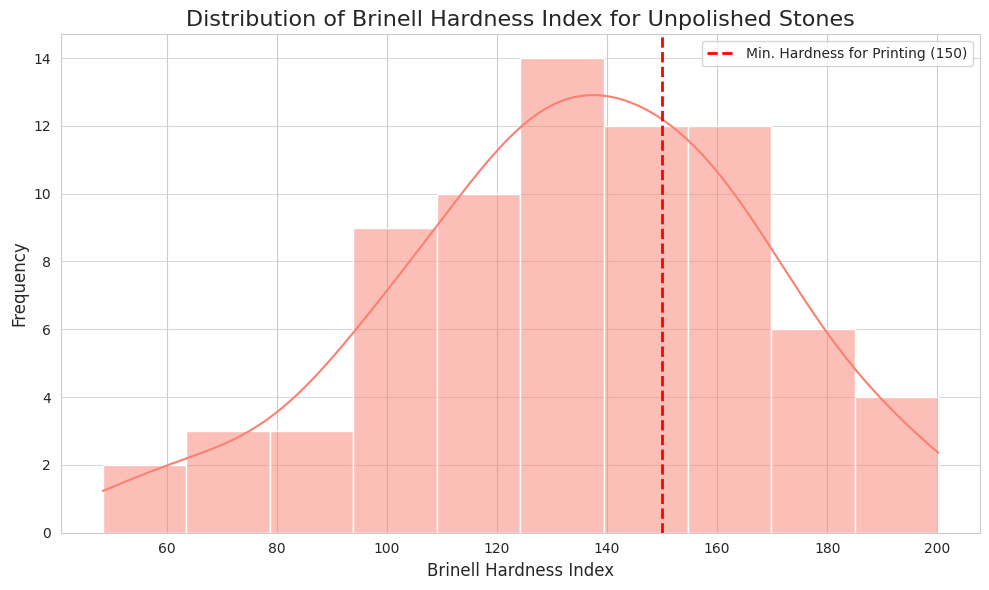

In [76]:
df.columns = ['Unpolished', 'Polished']

sns.set_style("whitegrid")

# --- Visualization for Question 3.1: Unpolished stones suitability ---

plt.figure(figsize=(10, 6))
sns.histplot(df['Unpolished'], kde=True, color='salmon', bins=10)
plt.axvline(x=150, color='red', linestyle='--', linewidth=2, label='Min. Hardness for Printing (150)')
plt.title('Distribution of Brinell Hardness Index for Unpolished Stones', fontsize=16)
plt.xlabel('Brinell Hardness Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


In [80]:
# --- For Question 3.2: Two-sample t-test for Unpolished vs. Polished stones ---
# Null Hypothesis (H0): mean_unpolished = mean_polished
# Alternative Hypothesis (H1): mean_unpolished != mean_polished
# Significance level (alpha): 0.05

# Accessing the 'Unpolished ' and 'Treated and Polished' columns
unpolished_hardness_two_sample = df['Unpolished']
polished_hardness = df['Polished']

# Perform two-sample independent t-test (using Welch's t-test by setting equal_var=False)
t_statistic_two_sample, p_value_two_sample = stats.ttest_ind(unpolished_hardness_two_sample, polished_hardness, equal_var=False)

print(f"Two-sample t-test for Unpolished vs. Polished stones:")
print(f"T-statistic: {t_statistic_two_sample:.4f}")
print(f"P-value: {p_value_two_sample:.4f}")

Two-sample t-test for Unpolished vs. Polished stones:
T-statistic: -3.2422
P-value: 0.0016


/tmp/ipython-input-82-1651055088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stone Type', y='Brinell Hardness Index', data=df_melted, palette={'Unpolished': 'salmon', 'Polished': 'skyblue'})


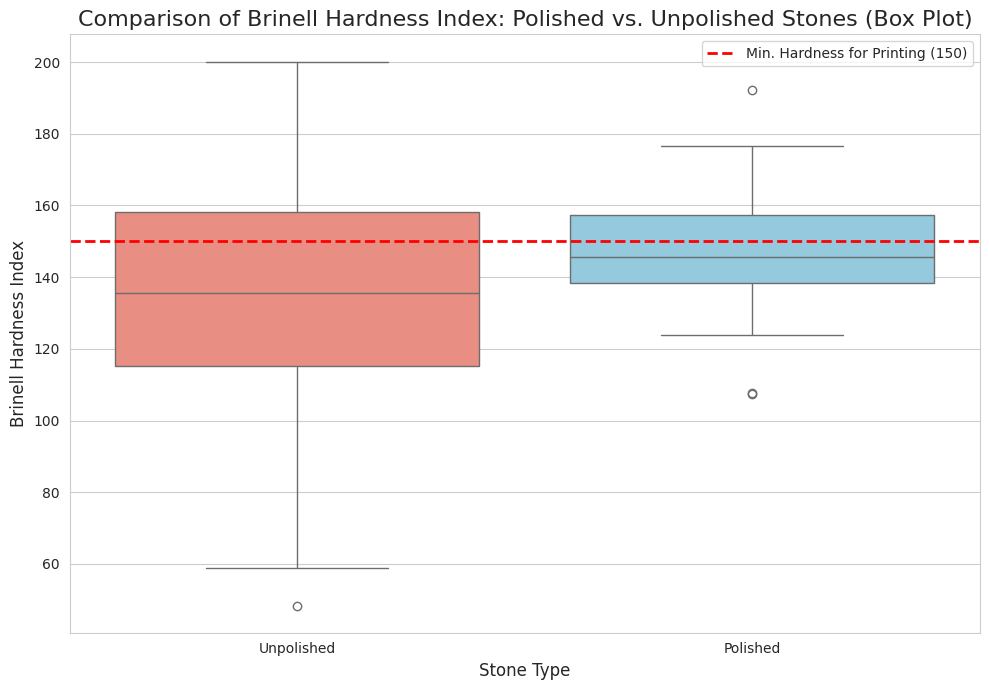

In [82]:
df_melted = df.melt(var_name='Stone Type', value_name='Brinell Hardness Index')

plt.figure(figsize=(10, 7))
sns.boxplot(x='Stone Type', y='Brinell Hardness Index', data=df_melted, palette={'Unpolished': 'salmon', 'Polished': 'skyblue'})
plt.axhline(y=150, color='red', linestyle='--', linewidth=2, label='Min. Hardness for Printing (150)')
plt.title('Comparison of Brinell Hardness Index: Polished vs. Unpolished Stones (Box Plot)', fontsize=16)
plt.xlabel('Stone Type', fontsize=12)
plt.ylabel('Brinell Hardness Index', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show();

In [48]:
# Compare p-value with significance level
if p_value_two_sample < alpha:
    print("Conclusion: Reject the null hypothesis. The mean hardness of polished and unpolished stones is not the same.")
else:
    print("Conclusion: Fail to reject the null hypothesis. The mean hardness of polished and unpolished stones is the same.")

Conclusion: Reject the null hypothesis. The mean hardness of polished and unpolished stones is not the same.


### Question 4

In [104]:
file_path = '/content/drive/MyDrive/Dental Hardness data.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Dentist,Method,Alloy,Temp,Response
0,1,1,1,1500,813
1,1,1,1,1600,792
2,1,1,1,1700,792
3,1,1,2,1500,907
4,1,1,2,1600,792


In [105]:
df.isnull().sum()

,0
Dentist,0
Method,0
Alloy,0
Temp,0
Response,0


There are no missing values

In [106]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values

In [102]:
from statsmodels.formula.api import ols      # For n-way ANOVA
from statsmodels.stats.anova import _get_covariance,anova_lm

In [88]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 4.1: One-Way ANOVA - Hardness by Dentist
model_4_1 = ols("Response ~ C(Dentist)", data=df).fit()
anova_4_1 = sm.stats.anova_lm(model_4_1, typ=2).round(4)
print("\n4.1 One-Way ANOVA (Dentist):")
print(anova_4_1)


4.1 One-Way ANOVA (Dentist):
                  sum_sq    df       F  PR(>F)
C(Dentist)  1.577946e+05   4.0  1.9345  0.1121
Residual    1.733301e+06  85.0     NaN     NaN


Text(0, 0.5, 'Hardness')

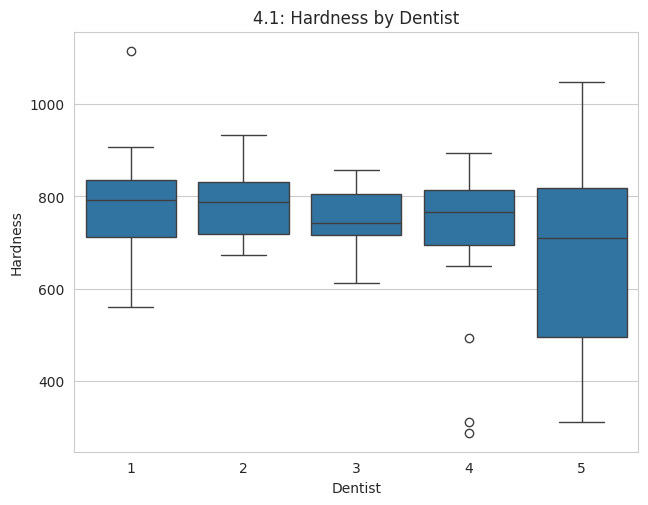

In [98]:
plt.figure(figsize=(16, 12))

# 4.1: Boxplot by Dentist
plt.subplot(2, 2, 1)
sns.boxplot(x="Dentist", y="Response", data=df)
plt.title("4.1: Hardness by Dentist")
plt.xlabel("Dentist")
plt.ylabel("Hardness")

In [89]:
# 4.2: One-Way ANOVA - Hardness by Method
model_4_2 = ols("Response ~ C(Method)", data=df).fit()
anova_4_2 = sm.stats.anova_lm(model_4_2, typ=2).round(4)
print("\n4.2 One-Way ANOVA (Method):")
print(anova_4_2)


4.2 One-Way ANOVA (Method):
                 sum_sq    df        F  PR(>F)
C(Method)  5.934275e+05   2.0  19.8927     0.0
Residual   1.297668e+06  87.0      NaN     NaN


Text(0, 0.5, 'Hardness')

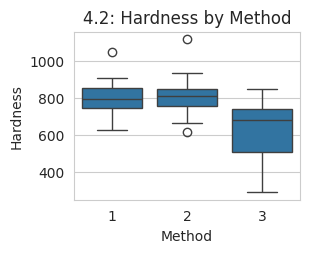

In [99]:
# 4.2: Boxplot by Method
plt.subplot(2, 2, 2)
sns.boxplot(x="Method", y="Response", data=df)
plt.title("4.2: Hardness by Method")
plt.xlabel("Method")
plt.ylabel("Hardness")

In [93]:
# 4.3: Two-Way ANOVA per Alloy
print("\n4.3 Two-Way ANOVA with Interaction (per Alloy):")
for alloy_level in df["Alloy"].unique():
    df_alloy = df[df["Alloy"] == alloy_level]
    model = ols("Response ~ C(Dentist) * C(Method)", data=df_alloy).fit()
    anova_result = sm.stats.anova_lm(model, typ=2).round(4)
    print(f"\nAlloy {alloy_level}:")
    print(anova_result)


4.3 Two-Way ANOVA with Interaction (per Alloy):

Alloy 1:
                           sum_sq    df        F  PR(>F)
C(Dentist)            106683.6889   4.0   3.8996  0.0115
C(Method)             148472.1778   2.0  10.8543  0.0003
C(Dentist):C(Method)  185941.3778   8.0   3.3984  0.0068
Residual              205180.0000  30.0      NaN     NaN

Alloy 2:
                           sum_sq    df        F  PR(>F)
C(Dentist)             56797.9111   4.0   1.1062  0.3718
C(Method)             499640.4000   2.0  19.4612  0.0000
C(Dentist):C(Method)  197459.8222   8.0   1.9228  0.0932
Residual              385104.6667  30.0      NaN     NaN


Text(0, 0.5, 'Hardness')

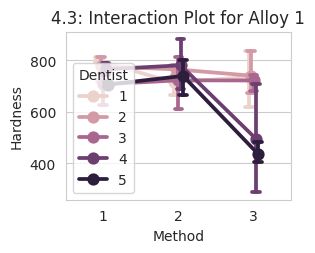

In [100]:
# 4.3: Interaction Plot for Alloy 1
plt.subplot(2, 2, 3)
sns.pointplot(x="Method", y="Response", hue="Dentist",
              data=df[df["Alloy"] == 1], dodge=True, markers='o', capsize=.1)
plt.title("4.3: Interaction Plot for Alloy 1")
plt.xlabel("Method")
plt.ylabel("Hardness")

In [95]:
# 4.4: Full Two-Way ANOVA on all data
full_model = ols("Response ~ C(Dentist) * C(Method) * C(Alloy)", data=df).fit()
full_anova = sm.stats.anova_lm(full_model, typ=2).round(4)
print("\n4.4 Full Two-Way ANOVA:")
print(full_anova)


4.4 Full Two-Way ANOVA:
                                    sum_sq    df        F  PR(>F)
C(Dentist)                     157794.5556   4.0   4.0098  0.0060
C(Method)                      593427.4889   2.0  30.1597  0.0000
C(Alloy)                       105815.5111   1.0  10.7557  0.0017
C(Dentist):C(Method)           306471.8444   8.0   3.8939  0.0009
C(Dentist):C(Alloy)              5687.0444   4.0   0.1445  0.9647
C(Method):C(Alloy)              54685.0889   2.0   2.7793  0.0701
C(Dentist):C(Method):C(Alloy)   76929.3556   8.0   0.9774  0.4624
Residual                       590284.6667  60.0      NaN     NaN


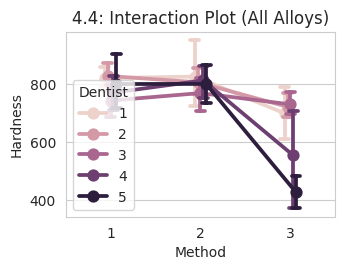

In [101]:
# 4.4: Interaction Plot (All Data)
plt.subplot(2, 2, 4)
sns.pointplot(x="Method", y="Response", hue="Dentist",
              data=df, dodge=True, markers='o', capsize=.1)
plt.title("4.4: Interaction Plot (All Alloys)")
plt.xlabel("Method")
plt.ylabel("Hardness")

plt.tight_layout()
plt.show()

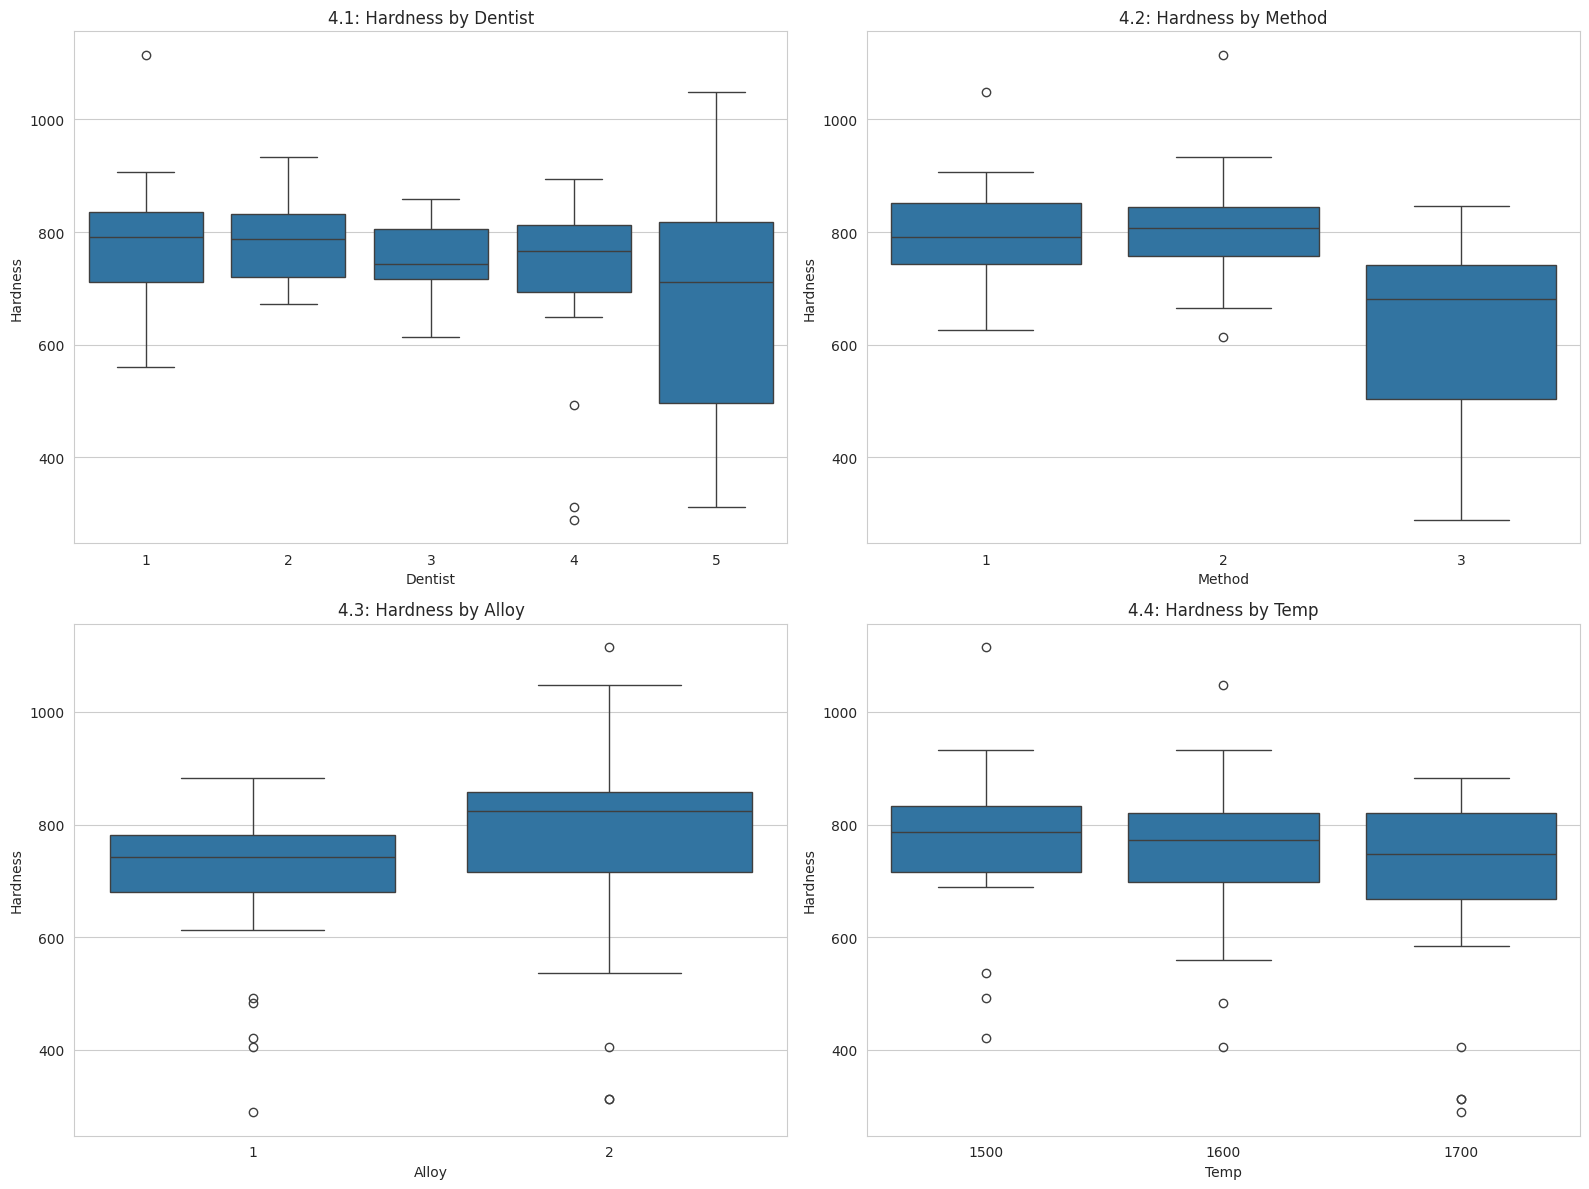

In [97]:
plt.figure(figsize=(16, 12))

# 4.1: Boxplot by Dentist
plt.subplot(2, 2, 1)
sns.boxplot(x="Dentist", y="Response", data=df)
plt.title("4.1: Hardness by Dentist")
plt.xlabel("Dentist")
plt.ylabel("Hardness")

# 4.2: Boxplot by Method
plt.subplot(2, 2, 2)
sns.boxplot(x="Method", y="Response", data=df)
plt.title("4.2: Hardness by Method")
plt.xlabel("Method")
plt.ylabel("Hardness")

# 4.3: Boxplot by Alloy
plt.subplot(2, 2, 3)
sns.boxplot(x="Alloy", y="Response", data=df)
plt.title("4.3: Hardness by Alloy")
plt.xlabel("Alloy")
plt.ylabel("Hardness")

# 4.4: Boxplot by Temp
plt.subplot(2, 2, 4)
sns.boxplot(x="Temp", y="Response", data=df)
plt.title("4.4: Hardness by Temp")
plt.xlabel("Temp")
plt.ylabel("Hardness")

plt.tight_layout()
plt.show()